### Insight Discovery through EDA

It is designed to solve a critical financial-security problem—discovering hidden fraud patterns by transforming cleaned transaction data into actionable business intelligence.

Fraud detection systems do not become effective merely because transaction data has been cleaned. Businesses still need to understand where, when, how, and under what circumstances fraudulent transactions occur. A dataset may contain thousands or millions of perfectly valid records, ***but without exploratory analysis, important patterns can remain hidden inside them***.

This project uses `Python-based Exploratory Data Analysis (EDA)` to investigate transaction behavior, compare fraudulent and legitimate transactions, uncover high-risk categories and locations, analyze transaction amounts and timing, and identify relationships between customer, merchant, geographic, and transactional characteristics.

### Exploring DATA:
To evaluate true risk, we must separate **volume from rate**:
* A **high raw count** of fraud in a high-volume category is often just normal exposure.
* A **high fraud rate** in a low-volume category is an actionable threat vector.

Exploratory Data Analysis (EDA) bridges this gap by shifting our view from total counts to proportions, revealing where true operational risk actually lives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

train_path = Path("../Datasets_MLmodels/Fraud/P03_outputs/fraudTrain_clean.csv")
test_path = Path("../Datasets_MLmodels/Fraud/P03_outputs/fraudTest_clean.csv")

output_dir = Path("../Datasets_MLmodels/Fraud/P04_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
print("=" * 75)
print("PROJECT 04 - INSIGHT DISCOVERY THROUGH EDA")
print("=" * 75)

print("\nChecking Project 03 outputs...\n")
if not train_path.exists():
    raise FileNotFoundError(f"Clean training dataset not found:\n{train_path}")

if not test_path.exists():
    raise FileNotFoundError(f"Clean testing dataset not found:\n{test_path}")

print("Clean training dataset found at:")
print(train_path)

print("\nClean testing dataset found at:")
print(test_path)

PROJECT 04 - INSIGHT DISCOVERY THROUGH EDA

Checking Project 03 outputs...

Clean training dataset found at:
..\Datasets_MLmodels\Fraud\P03_outputs\fraudTrain_clean.csv

Clean testing dataset found at:
..\Datasets_MLmodels\Fraud\P03_outputs\fraudTest_clean.csv


In [3]:
fraud_train = pd.read_csv(train_path)
fraud_test = pd.read_csv(test_path)

print("Clean datasets loaded successfully.")

Clean datasets loaded successfully.


In [4]:
fraud_train["dataset_split"] = "train"
fraud_test["dataset_split"] = "test"

fraud = pd.concat([fraud_train, fraud_test], ignore_index=True)

print("Combined dataset shape:")
print(fraud.shape)

Combined dataset shape:
(1852394, 23)


In [5]:
print("=" * 57)
print("\t\t DATASET OVERVIEW")
print("=" * 57)

print("\nNumber of rows:", fraud.shape[0])
print("Number of columns:", fraud.shape[1])

print("\nColumns:")
fraud.columns.tolist()

		 DATASET OVERVIEW

Number of rows: 1852394
Number of columns: 23

Columns:


['trans_date_trans_time',
 'cc_num',
 'merchant',
 'category',
 'amt',
 'first',
 'last',
 'gender',
 'street',
 'city',
 'state',
 'zip',
 'lat',
 'long',
 'city_pop',
 'job',
 'dob',
 'trans_num',
 'unix_time',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'dataset_split']

In [6]:
print("\nMissing values:")
print(fraud.isnull().sum().sum())

print("\nDuplicate rows:")
fraud.duplicated().sum()


Missing values:
0

Duplicate rows:


np.int64(0)

In [7]:
print("\nData types:")
print(fraud.dtypes)


Data types:
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dataset_split             object
dtype: object


In [8]:
datetime_columns = ["trans_date_trans_time", "dob"]

for column in datetime_columns:
    if column in fraud.columns:
        fraud[column] = pd.to_datetime(fraud[column], errors="coerce")
if "trans_date_trans_time" in fraud.columns:
    fraud["transaction_date"] = (fraud["trans_date_trans_time"].dt.date)
    fraud["transaction_hour"] = (fraud["trans_date_trans_time"].dt.hour)
    fraud["transaction_day"] = (fraud["trans_date_trans_time"].dt.day)
    fraud["transaction_month"] = (fraud["trans_date_trans_time"].dt.month)
    fraud["transaction_year"] = (fraud["trans_date_trans_time"].dt.year)
    fraud["day_of_week"] = (fraud["trans_date_trans_time"].dt.day_name())
    fraud["is_weekend"] = (fraud["trans_date_trans_time"].dt.dayofweek >= 5)

In [9]:
if "dob" in fraud.columns and "trans_date_trans_time" in fraud.columns:
    fraud["customer_age"] = (
        (fraud["trans_date_trans_time"] - fraud["dob"]).dt.days / 365.25
    )
    fraud["customer_age"] = (fraud["customer_age"].round(1))

In [10]:
if "customer_age" in fraud.columns:
    age_bins = [0, 18, 25, 35, 45, 55, 65, 200]
    age_labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

    fraud["age_group"] = pd.cut(
        fraud["customer_age"],
        bins=age_bins,
        labels=age_labels,
        right=False
    )

In [13]:
print("\n" + "=" * 111)
print("\t\t\t\t\t\tNUMERICAL SUMMARY")
print("=" * 111)

fraud.describe(include="number").T


						NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
cc_num,1852394.0,4.173860e+17,1.309115e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1852394.0,7.006357e+01,1.592540e+02,1.000000e+00,9.640000e+00,4.745000e+01,8.310000e+01,2.894890e+04
zip,1852394.0,4.881326e+04,2.688185e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.992100e+04
lat,1852394.0,3.853931e+01,5.071470e+00,2.002710e+01,3.466890e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1852394.0,-9.022783e+01,1.374789e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1852394.0,8.864367e+04,3.014876e+05,2.300000e+01,7.410000e+02,2.443000e+03,2.032800e+04,2.906700e+06
unix_time,1852394.0,1.358674e+09,1.819508e+07,1.325376e+09,1.343017e+09,1.357089e+09,1.374581e+09,1.388534e+09
merch_lat,1852394.0,3.853898e+01,5.105604e+00,1.902742e+01,3.474012e+01,3.936890e+01,4.195626e+01,6.751027e+01
merch_long,1852394.0,-9.022794e+01,1.375969e+01,-1.666716e+02,-9.689944e+01,-8.744069e+01,-8.024511e+01,-6.695090e+01
is_fraud,1852394.0,5.210015e-03,7.199217e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [16]:
print("\n" + "=" * 28)
print("  FRAUD DISTRIBUTION")
print("=" * 28)

fraud_counts = fraud["is_fraud"].value_counts()
fraud_percentages = (
    fraud["is_fraud"].value_counts(normalize=True).mul(100).round(2)
)
fraud_distribution = pd.DataFrame({
    "transaction_count": fraud_counts,
    "percentage": fraud_percentages
})

fraud_distribution


  FRAUD DISTRIBUTION


,transaction_count,percentage
is_fraud,,
0,1842743,99.48
1,9651,0.52


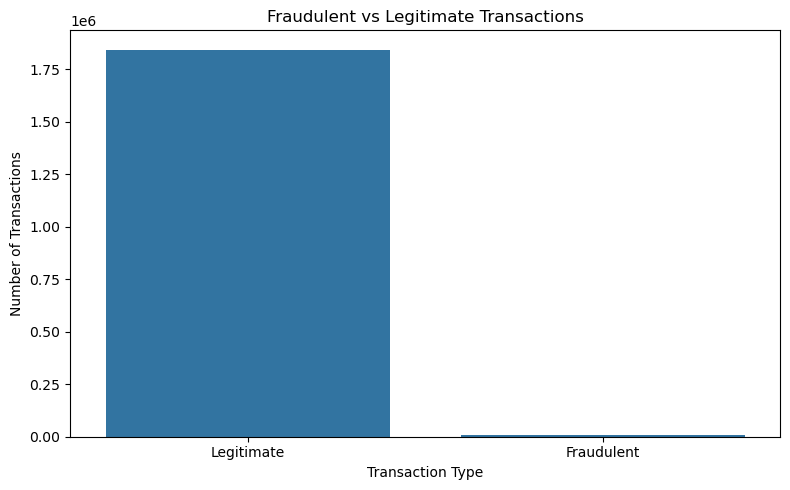

In [17]:
#FRAUD VS LEGITIMATE TRANSACTIONS
plt.figure(figsize=(8, 5))

sns.countplot(
    data=fraud,
    x="is_fraud"
)

plt.title("Fraudulent vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)
plt.tight_layout()

plt.savefig(
    output_dir / "01_fraud_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

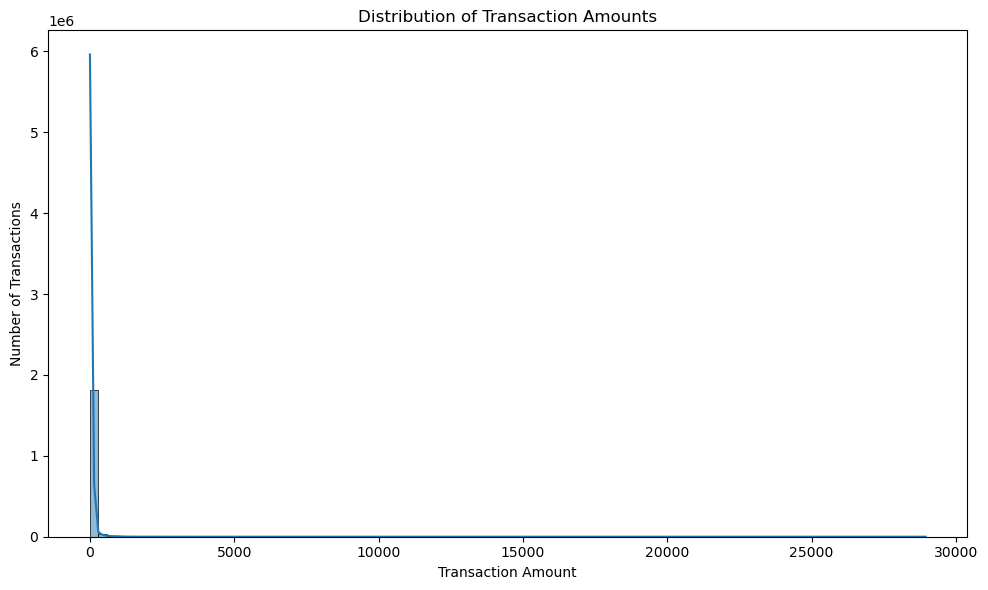

In [18]:
#TRANSACTION AMOUNT DISTRIBUTION
plt.figure(figsize=(10, 6))

sns.histplot(
    data=fraud,
    x="amt",
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    output_dir / "02_transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

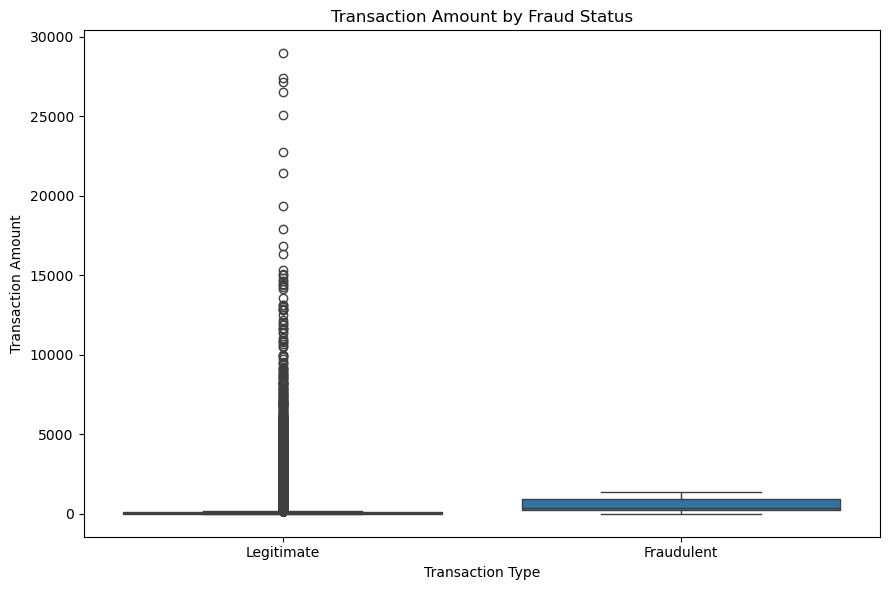

In [19]:
#TRANSACTION AMOUNT BY FRAUD STATUS
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=fraud,
    x="is_fraud",
    y="amt"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraudulent"]
)
plt.tight_layout()

plt.savefig(
    output_dir / "03_amount_by_fraud_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
#FRAUD AMOUNT STATISTICS
amount_summary = (
    fraud
    .groupby("is_fraud")["amt"]
    .agg(
        transaction_count="count",
        average_amount="mean",
        median_amount="median",
        minimum_amount="min",
        maximum_amount="max"
    )
    .round(2)
)

print("=" * 75)
print("\t\t TRANSACTION AMOUNT SUMMARY BY FRAUD STATUS")
print("=" * 75)

amount_summary

		 TRANSACTION AMOUNT SUMMARY BY FRAUD STATUS


,transaction_count,average_amount,median_amount,minimum_amount,maximum_amount
is_fraud,,,,,
0,1842743,67.65,47.24,1.00,28948.90
1,9651,530.66,390.00,1.06,1376.04


In [21]:
category_summary = (
    fraud
    .groupby("category")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraudulent_transactions=("is_fraud", "sum"),
        average_amount=("amt", "mean")
    )
)
category_summary["fraud_rate"] = (
    category_summary["fraudulent_transactions"]
    / category_summary["total_transactions"] * 100
)
category_summary = (
    category_summary
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .round(2)
)
print("=" * 65)
print("\t\t  FRAUD BY TRANSACTION CATEGORY")
print("=" * 65)

category_summary

		  FRAUD BY TRANSACTION CATEGORY


,total_transactions,fraudulent_transactions,average_amount,fraud_rate
category,,,,
shopping_net,139322,2219,86.94,1.59
misc_net,90654,1182,80.18,1.30
grocery_pos,176191,2228,116.64,1.26
shopping_pos,166463,1056,78.91,0.63
gas_transport,188029,772,63.48,0.41
misc_pos,114229,322,62.68,0.28
grocery_net,64878,175,53.69,0.27
travel,57956,156,111.77,0.27
personal_care,130085,290,48.05,0.22


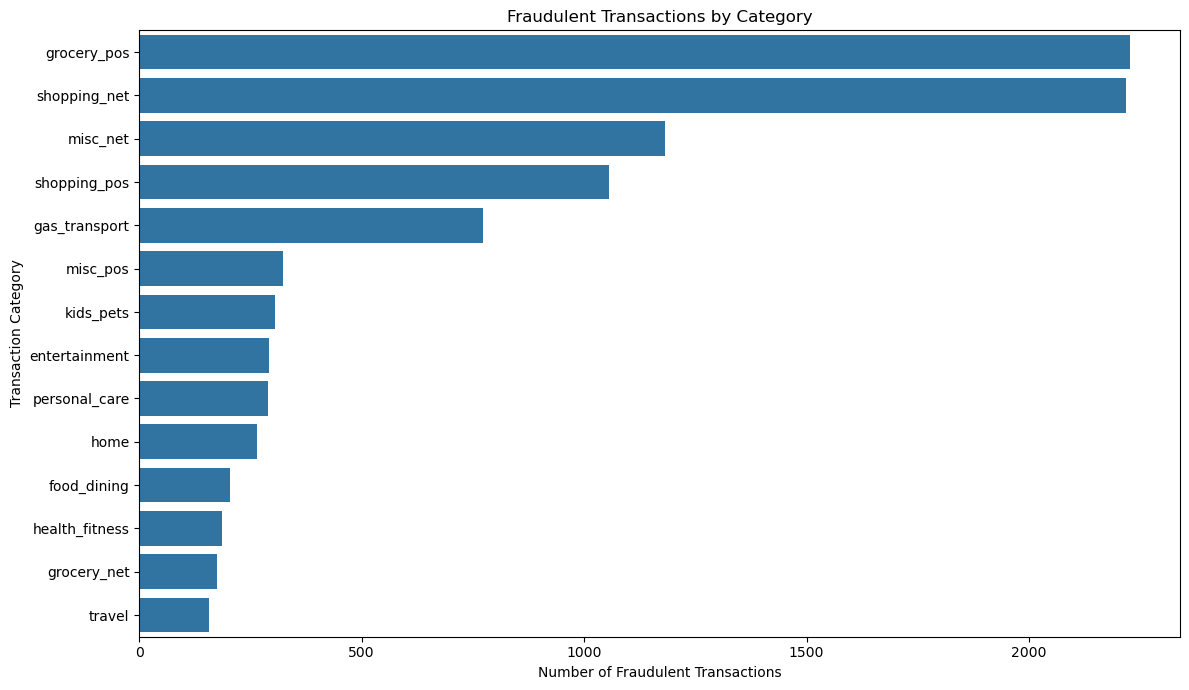

In [22]:
category_count_plot = (
    category_summary
    .sort_values(
        "fraudulent_transactions",
        ascending=False
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_count_plot.reset_index(),
    x="fraudulent_transactions",
    y="category"
)
plt.title("Fraudulent Transactions by Category")
plt.xlabel("Number of Fraudulent Transactions")
plt.ylabel("Transaction Category")

plt.tight_layout()

plt.savefig(
    output_dir / "04_fraud_count_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

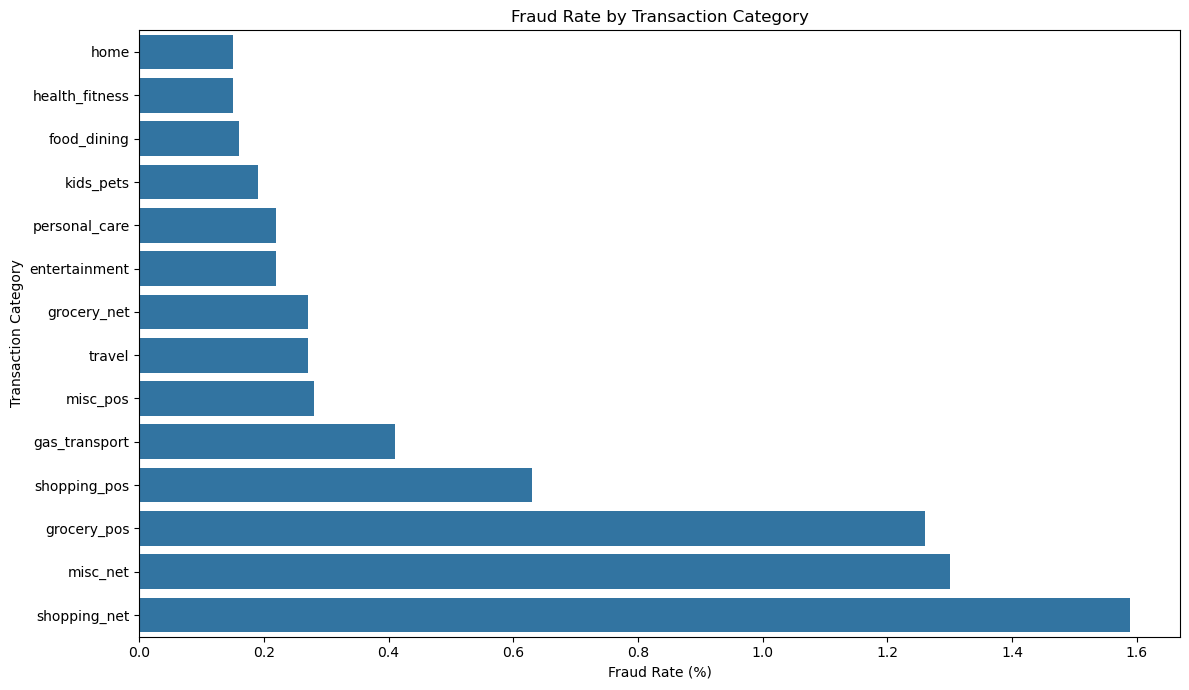

In [23]:
category_rate_plot = (
    category_summary
    .sort_values(
        "fraud_rate",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=category_rate_plot.reset_index(),
    x="fraud_rate",
    y="category"
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Category")

plt.tight_layout()

plt.savefig(
    output_dir / "05_fraud_rate_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
if "gender" in fraud.columns:
    gender_summary = (
        fraud
        .groupby("gender")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum"),
            average_amount=("amt", "mean")
        )
    )
    gender_summary["fraud_rate"] = (
        gender_summary["fraudulent_transactions"]
        / gender_summary["total_transactions"] * 100
    )
    gender_summary = gender_summary.round(2)

    print("\n" + "=" * 53)
    print("\t\t  FRAUD BY GENDER")
    print("=" * 53)

gender_summary


		  FRAUD BY GENDER


,total_transactions,fraudulent_transactions,average_amount,fraud_rate
gender,,,,
F,1014749,4899,69.96,0.48
M,837645,4752,70.19,0.57


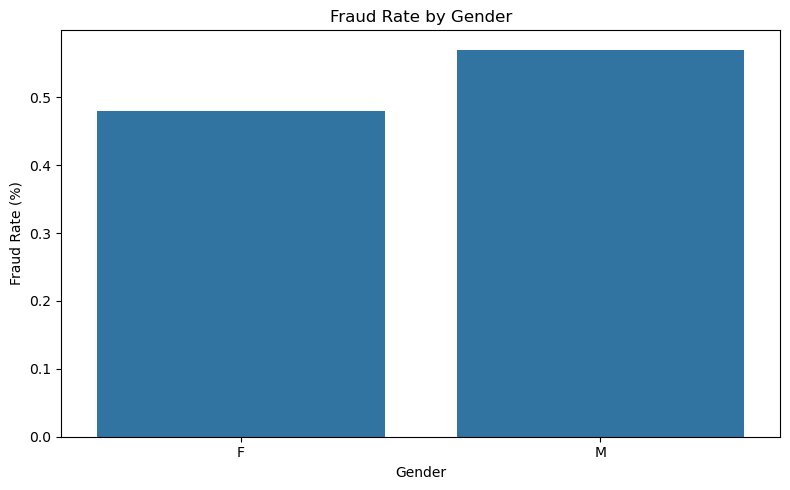

In [25]:
if "gender" in fraud.columns:
    
    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=gender_summary.reset_index(),
        x="gender",
        y="fraud_rate"
    )

    plt.title("Fraud Rate by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Fraud Rate (%)")

    plt.tight_layout()
    
    plt.savefig(
        output_dir / "06_fraud_rate_by_gender.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [26]:
if "transaction_hour" in fraud.columns:
    hourly_summary = (
        fraud
        .groupby("transaction_hour")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    hourly_summary["fraud_rate"] = (
        hourly_summary["fraudulent_transactions"]
        / hourly_summary["total_transactions"] * 100
    )
    hourly_summary = hourly_summary.round(2)

    print("=" * 55)
    print("\t\tFRAUD BY TRANSACTION HOUR")
    print("=" * 55)

hourly_summary

		FRAUD BY TRANSACTION HOUR


,total_transactions,fraudulent_transactions,fraud_rate
transaction_hour,,,
0,60655,823,1.36
1,61330,827,1.35
2,60796,793,1.30
3,60968,803,1.32
4,59938,61,0.10
5,60088,80,0.13
6,60406,54,0.09
7,60301,72,0.12
8,60498,59,0.10


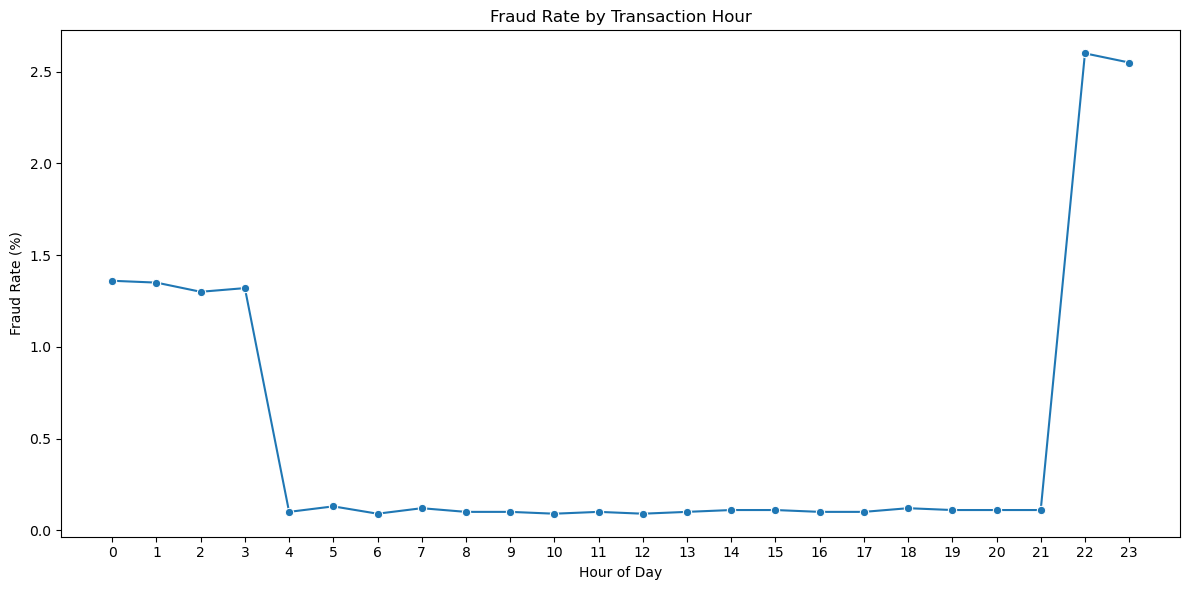

In [27]:
if "transaction_hour" in fraud.columns:

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=hourly_summary,
        x=hourly_summary.index,
        y="fraud_rate",
        marker="o"
    )

    plt.title("Fraud Rate by Transaction Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(range(0, 24))

    plt.tight_layout()

    plt.savefig(
        output_dir / "07_fraud_rate_by_hour.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

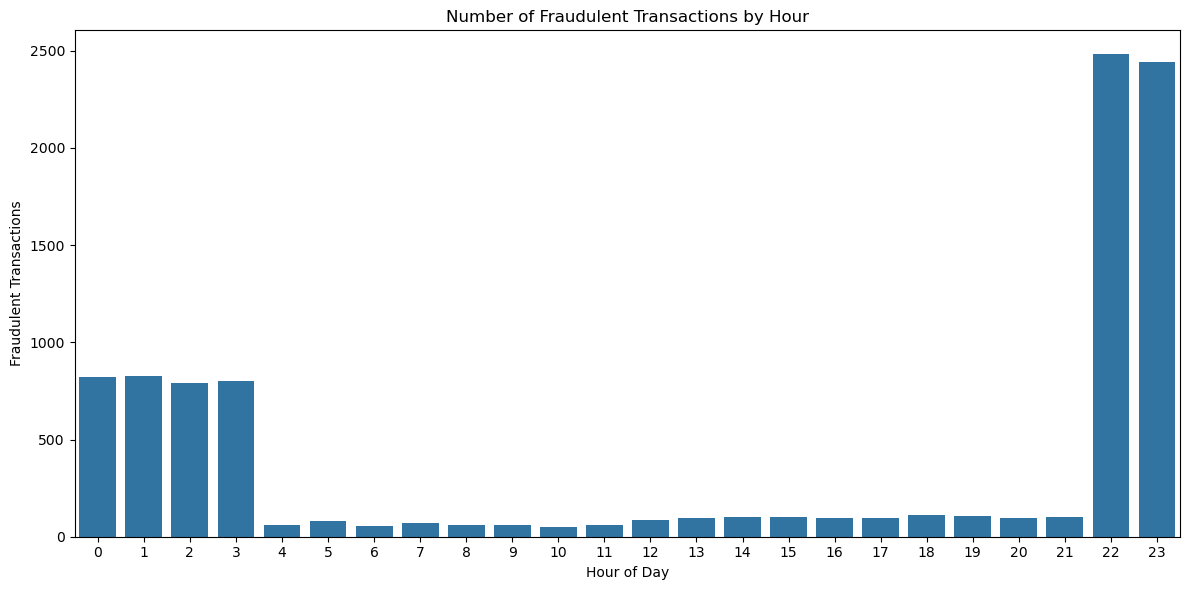

In [28]:
if "transaction_hour" in fraud.columns:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=hourly_summary.reset_index(),
        x="transaction_hour",
        y="fraudulent_transactions"
    )

    plt.title("Number of Fraudulent Transactions by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraudulent Transactions")

    plt.tight_layout()

    plt.savefig(
        output_dir / "08_fraud_count_by_hour.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [29]:
if "day_of_week" in fraud.columns:
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekday_summary = (
        fraud
        .groupby("day_of_week")
        .agg(
                total_transactions=("is_fraud", "size"),
                fraudulent_transactions=("is_fraud", "sum")
            )
            .reindex(weekday_order)
        )
    weekday_summary["fraud_rate"] = (
        weekday_summary["fraudulent_transactions"]
        / weekday_summary["total_transactions"] * 100
        )
    weekday_summary = weekday_summary.round(2)

    print("=" * 67)
    print("\t\t\tFRAUD BY DAY OF WEEK")
    print("=" * 67)

weekday_summary

			FRAUD BY DAY OF WEEK


,total_transactions,fraudulent_transactions,fraud_rate
day_of_week,,,
Monday,369418,1484,0.40
Tuesday,270340,1266,0.47
Wednesday,183913,1125,0.61
Thursday,206741,1317,0.64
Friday,215078,1376,0.64
Saturday,263227,1493,0.57
Sunday,343677,1590,0.46


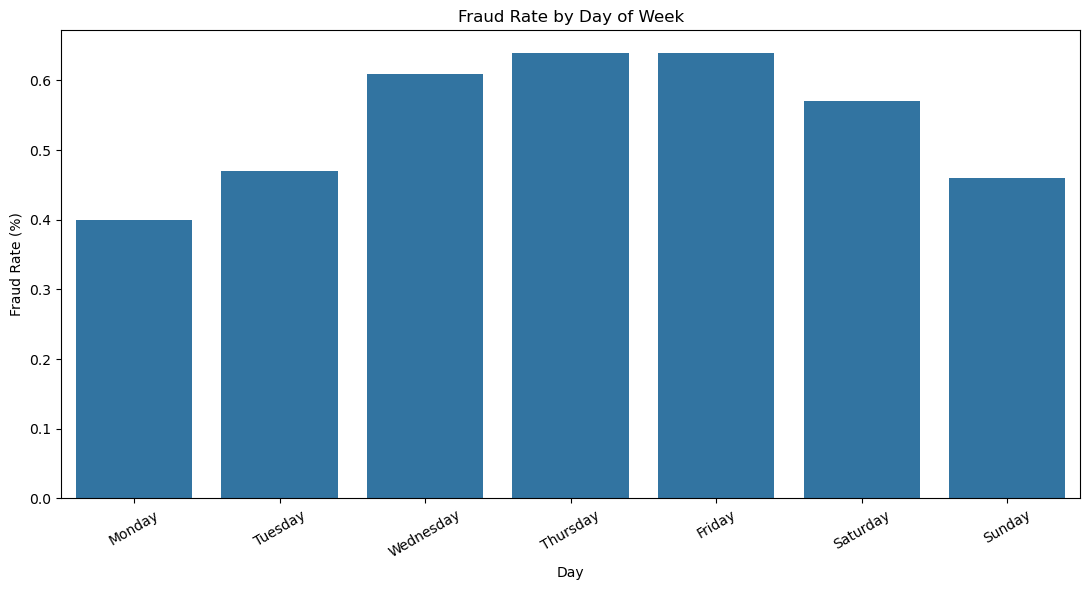

In [30]:
if "day_of_week" in fraud.columns:

    plt.figure(figsize=(11, 6))

    sns.barplot(
        data=weekday_summary.reset_index(),
        x="day_of_week",
        y="fraud_rate"
    )

    plt.title("Fraud Rate by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Fraud Rate (%)")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.savefig(
        output_dir / "09_fraud_rate_by_day.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [31]:
if "is_weekend" in fraud.columns:
    weekend_summary = (
        fraud
        .groupby("is_weekend")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    weekend_summary["fraud_rate"] = (
        weekend_summary["fraudulent_transactions"]
        / weekend_summary["total_transactions"] * 100
    )
    weekend_summary = weekend_summary.round(2)
    weekend_summary.index = [
        "Weekday" if value is False else "Weekend"
        for value in weekend_summary.index
    ]
    print("=" * 65)
    print("\t\t      WEEKDAY VS WEEKEND FRAUD")
    print("=" * 65)

weekend_summary

		      WEEKDAY VS WEEKEND FRAUD


,total_transactions,fraudulent_transactions,fraud_rate
Weekday,1245490,6568,0.53
Weekend,606904,3083,0.51


In [32]:
if "state" in fraud.columns:
    state_summary = (
        fraud
        .groupby("state")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    state_summary["fraud_rate"] = (
        state_summary["fraudulent_transactions"]
        / state_summary["total_transactions"] * 100
    )
    state_summary_filtered = state_summary[
        state_summary["total_transactions"] >= 100
    ].copy()
    state_summary_filtered = (
        state_summary_filtered
        .sort_values(
            "fraud_rate",
            ascending=False
        )
        .round(2)
    )
    print("=" * 65)
    print("\t\t  HIGHEST FRAUD-RATE STATES")
    print("=" * 65)
    
state_summary_filtered.head(15)

		  HIGHEST FRAUD-RATE STATES


,total_transactions,fraudulent_transactions,fraud_rate
state,,,
RI,745,15,2.01
AK,2963,50,1.69
OR,26408,197,0.75
NH,11727,79,0.67
VA,41756,273,0.65
TN,24913,159,0.64
NE,34425,216,0.63
MN,45433,280,0.62
NY,119419,730,0.61


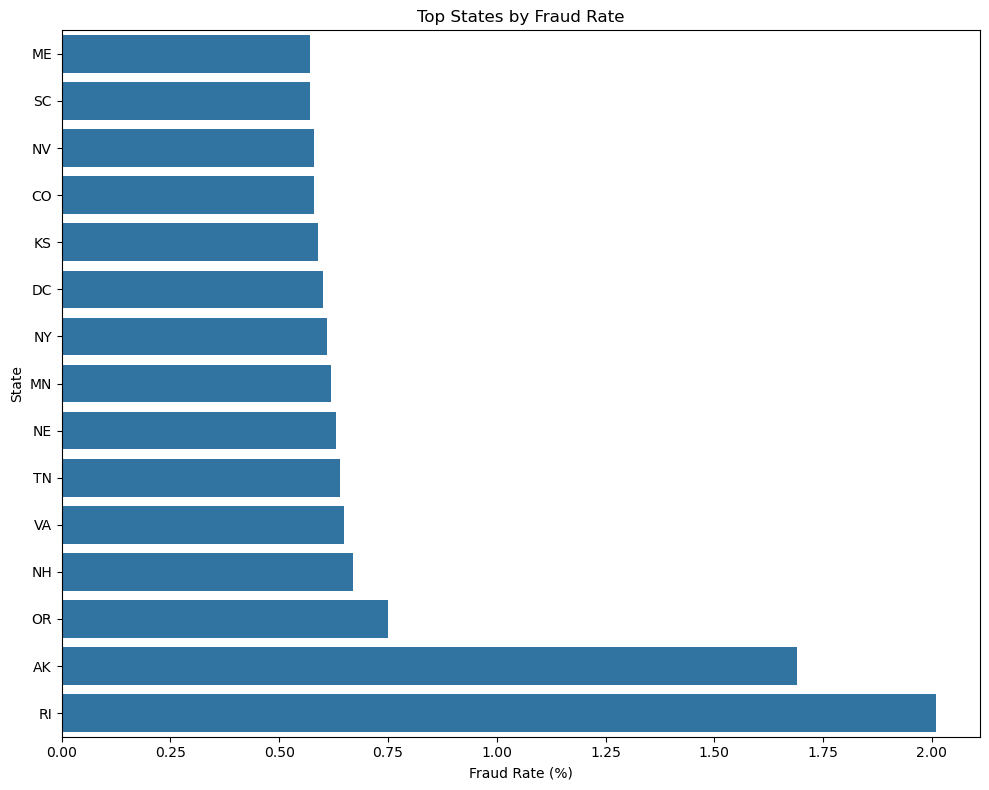

In [33]:
if "state" in fraud.columns:

    top_states = (
        state_summary_filtered
        .head(15)
        .sort_values("fraud_rate")
    )

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=top_states.reset_index(),
        x="fraud_rate",
        y="state"
    )

    plt.title("Top States by Fraud Rate")
    plt.xlabel("Fraud Rate (%)")
    plt.ylabel("State")

    plt.tight_layout()

    plt.savefig(
        output_dir / "10_top_states_fraud_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [34]:
if "city" in fraud.columns:
    city_summary = (
        fraud
        .groupby("city")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    city_summary["fraud_rate"] = (
        city_summary["fraudulent_transactions"]
        / city_summary["total_transactions"] * 100
    )
    city_summary_filtered = city_summary[
        city_summary["total_transactions"] >= 50
    ].copy()
    city_summary_filtered = (
        city_summary_filtered
        .sort_values(
            "fraud_rate",
            ascending=False
        )
        .round(2)
    )
    print("=" * 65)
    print("\t\t  TOP CITIES BY FRAUD RATE")
    print("=" * 65)
    
city_summary_filtered.head(15)

		  TOP CITIES BY FRAUD RATE


,total_transactions,fraudulent_transactions,fraud_rate
city,,,
Clearwater,753,24,3.19
Aurora,750,23,3.07
Benton,750,20,2.67
Jay,743,16,2.15
Chatham,743,16,2.15
Moscow,745,16,2.15
Riverview,741,15,2.02
Howes Cave,743,15,2.02
Boulder,743,15,2.02


In [35]:
if "merchant" in fraud.columns:
    merchant_summary = (
        fraud
        .groupby("merchant")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum"),
            average_amount=("amt", "mean")
        )
    )
    merchant_summary["fraud_rate"] = (
        merchant_summary["fraudulent_transactions"]
        / merchant_summary["total_transactions"] * 100
    )
    merchant_summary_filtered = merchant_summary[
        merchant_summary["total_transactions"] >= 50
    ].copy()
    merchant_summary_filtered = (
        merchant_summary_filtered
        .sort_values(
            "fraud_rate",
            ascending=False
        )
        .round(2)
    )
    print("=" * 60)
    print("\t\t TOP MERCHANTS BY FRAUD RATE")
    print("=" * 60)
    
merchant_summary_filtered.head(15)

		 TOP MERCHANTS BY FRAUD RATE


,total_transactions,fraudulent_transactions,average_amount,fraud_rate
merchant,,,,
fraud_Kozey-Boehm,2758,60,90.63,2.18
"fraud_Herman, Treutel and Dickens",1870,38,85.09,2.03
fraud_Terry-Huel,2864,56,94.00,1.96
fraud_Kerluke-Abshire,2635,50,93.09,1.90
"fraud_Mosciski, Ziemann and Farrell",2821,53,87.68,1.88
"fraud_Schmeler, Bashirian and Price",2788,52,94.03,1.87
fraud_Kuhic LLC,2842,53,90.18,1.86
fraud_Jast Ltd,2757,51,86.83,1.85
"fraud_Langworth, Boehm and Gulgowski",2817,52,84.48,1.85


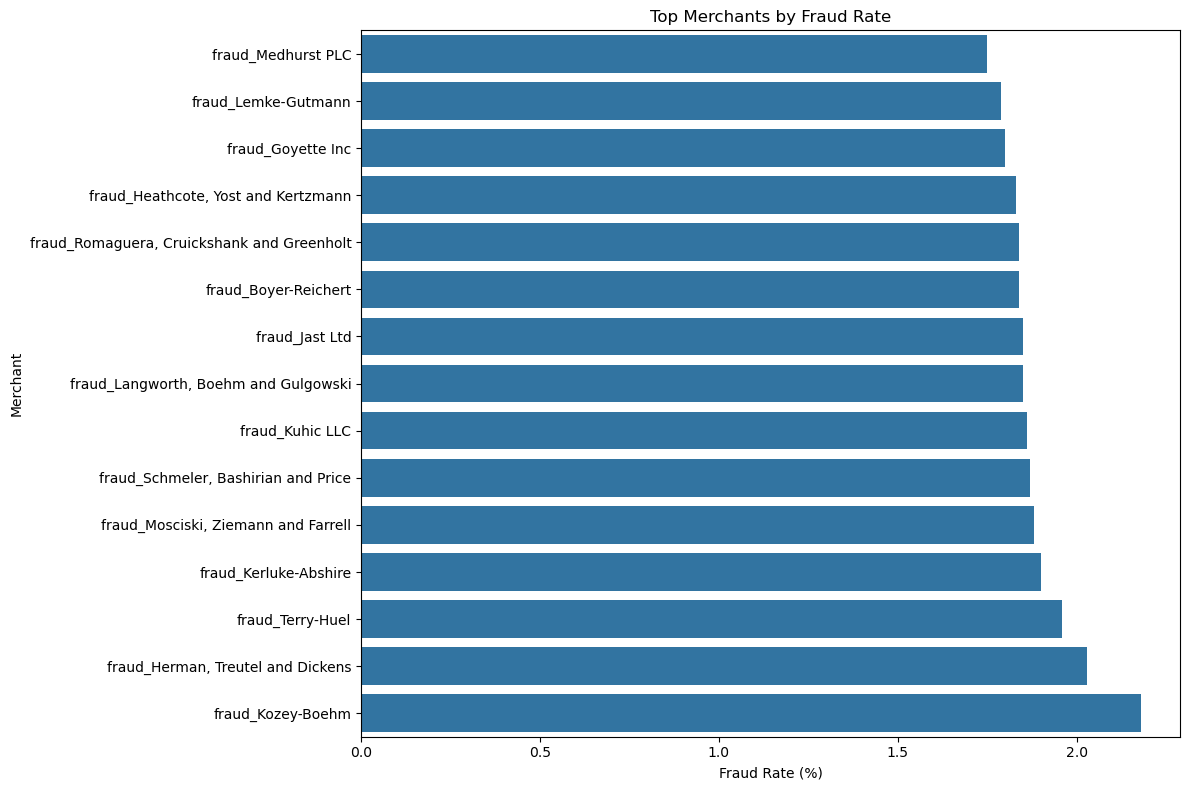

In [36]:
if "merchant" in fraud.columns:

    top_merchants = (
        merchant_summary_filtered
        .head(15)
        .sort_values("fraud_rate")
    )

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=top_merchants.reset_index(),
        x="fraud_rate",
        y="merchant"
    )
    plt.title("Top Merchants by Fraud Rate")
    plt.xlabel("Fraud Rate (%)")
    plt.ylabel("Merchant")

    plt.tight_layout()

    plt.savefig(
        output_dir / "11_top_merchants_fraud_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [37]:
if "age_group" in fraud.columns:
    age_summary = (
        fraud
        .groupby("age_group", observed=True)
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    age_summary["fraud_rate"] = (
        age_summary["fraudulent_transactions"]
        / age_summary["total_transactions"] * 100
    )
    age_summary = age_summary.round(2)

    print("=" * 67)
    print("\t\t  FRAUD BY CUSTOMER AGE GROUP")
    print("=" * 67)

age_summary

		  FRAUD BY CUSTOMER AGE GROUP


,total_transactions,fraudulent_transactions,fraud_rate
age_group,,,
<18,21653,118,0.54
18-24,144920,799,0.55
25-34,399809,1801,0.45
35-44,393087,1556,0.40
45-54,374328,1928,0.52
55-64,232540,1584,0.68
65+,286057,1865,0.65


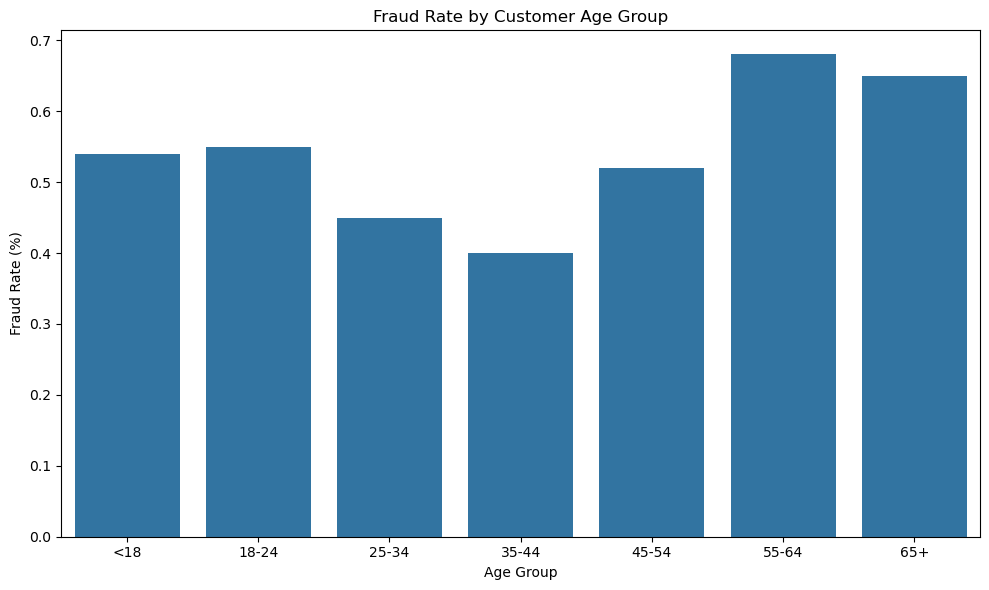

In [38]:
if "age_group" in fraud.columns:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=age_summary.reset_index(),
        x="age_group",
        y="fraud_rate"
    )

    plt.title("Fraud Rate by Customer Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Fraud Rate (%)")

    plt.tight_layout()

    plt.savefig(
        output_dir / "12_fraud_rate_by_age_group.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [39]:
numeric_features = fraud.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_features.corr()

print("=" * 67)
print("\t\t  CORRELATION WITH FRAUD TARGET")
print("=" * 67)

if "is_fraud" in correlation_matrix.columns:

    fraud_correlations = (
        correlation_matrix["is_fraud"]
        .sort_values(
            ascending=False
        )
    )
fraud_correlations

		  CORRELATION WITH FRAUD TARGET


is_fraud             1.000000
amt                  0.209308
transaction_hour     0.013196
customer_age         0.010682
lat                  0.002904
merch_lat            0.002778
long                 0.001022
merch_long           0.000999
city_pop             0.000325
transaction_day     -0.000131
cc_num              -0.001125
zip                 -0.002190
transaction_year    -0.006022
unix_time           -0.013329
transaction_month   -0.016417
Name: is_fraud, dtype: float64

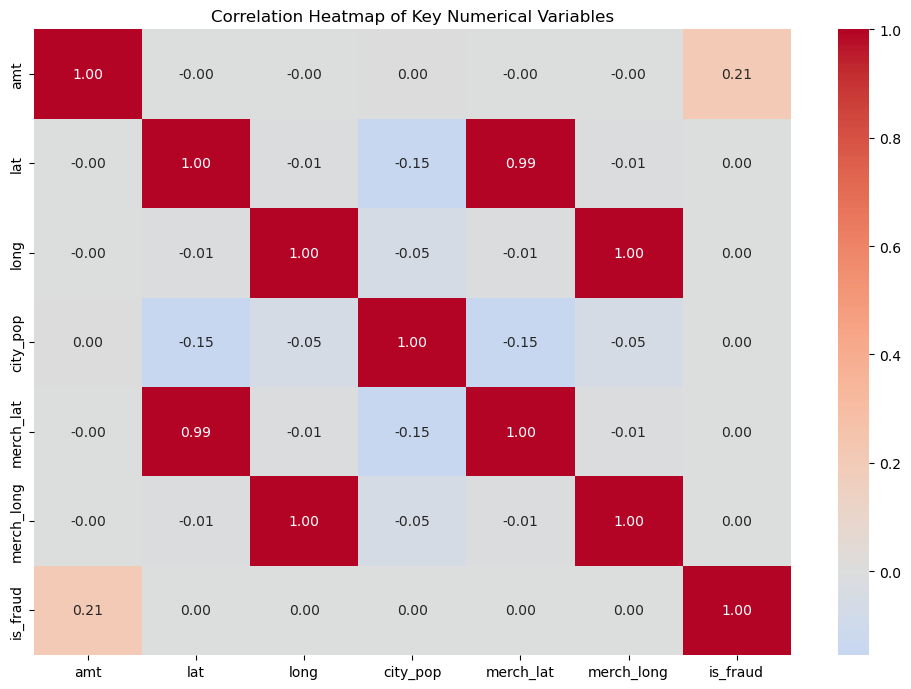

In [40]:
heatmap_columns = ["amt", "lat", "long", "city_pop", "merch_lat", "merch_long", "is_fraud"]
heatmap_columns = [
    column
    for column in heatmap_columns
    if column in fraud.columns
]
if len(heatmap_columns) >= 2:

    plt.figure(figsize=(10, 7))

    correlation_subset = (
        fraud[heatmap_columns]
        .corr()
    )

    sns.heatmap(
        correlation_subset,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )
    plt.title("Correlation Heatmap of Key Numerical Variables")

    plt.tight_layout()

    plt.savefig(
        output_dir / "13_correlation_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

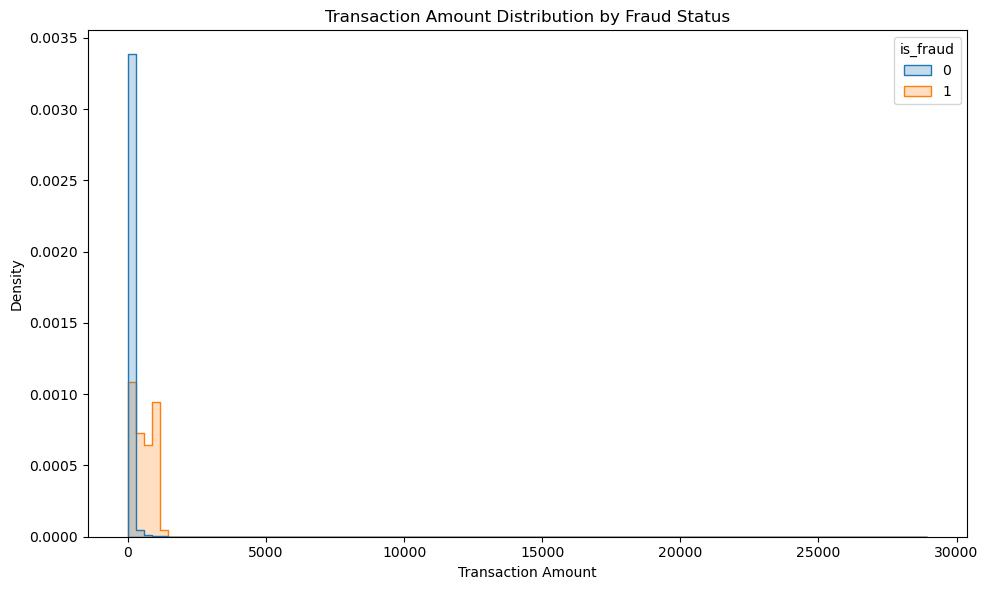

In [41]:
if "amt" in fraud.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=fraud,
        x="amt",
        hue="is_fraud",
        bins=100,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title("Transaction Amount Distribution by Fraud Status")
    plt.xlabel("Transaction Amount")
    plt.ylabel("Density")

    plt.tight_layout()

    plt.savefig(
        output_dir / "14_amount_distribution_fraud_status.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

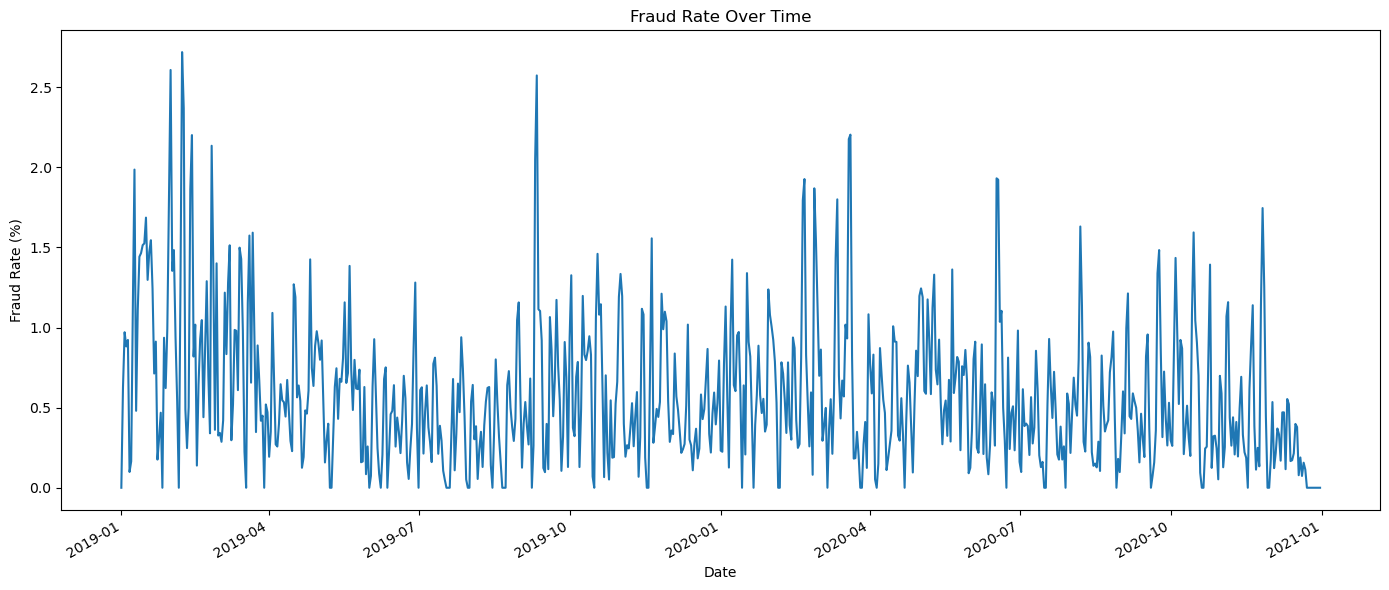

In [42]:
if "transaction_date" in fraud.columns:
    daily_summary = (
        fraud
        .groupby("transaction_date")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    daily_summary["fraud_rate"] = (
        daily_summary["fraudulent_transactions"]
        / daily_summary["total_transactions"] * 100
    )
    daily_summary.index = pd.to_datetime(
        daily_summary.index
    )

    plt.figure(figsize=(14, 6))

    daily_summary["fraud_rate"].plot()

    plt.title("Fraud Rate Over Time")
    plt.xlabel("Date")
    plt.ylabel("Fraud Rate (%)")

    plt.tight_layout()

    plt.savefig(
        output_dir / "15_fraud_rate_over_time.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [43]:
if "transaction_month" in fraud.columns:
    monthly_summary = (
        fraud
        .groupby("transaction_month")
        .agg(
            total_transactions=("is_fraud", "size"),
            fraudulent_transactions=("is_fraud", "sum")
        )
    )
    monthly_summary["fraud_rate"] = (
        monthly_summary["fraudulent_transactions"]
        / monthly_summary["total_transactions"] * 100
    )
    monthly_summary = monthly_summary.round(2)

    print("=" * 67)
    print("\t\t   MONTHLY FRAUD ANALYSIS")
    print("=" * 67)

monthly_summary

		   MONTHLY FRAUD ANALYSIS


,total_transactions,fraudulent_transactions,fraud_rate
transaction_month,,,
1,104727,849,0.81
2,97657,853,0.87
3,143789,938,0.65
4,134970,678,0.50
5,146875,935,0.64
6,173869,821,0.47
7,172444,652,0.38
8,176118,797,0.45
9,140185,758,0.54


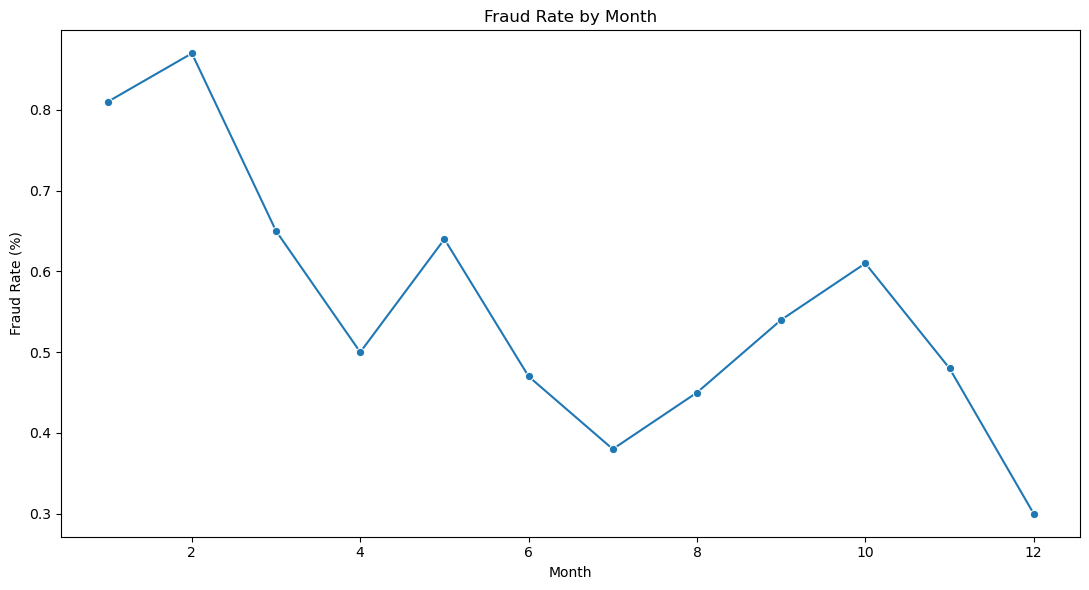

In [44]:
if "transaction_month" in fraud.columns:

    plt.figure(figsize=(11, 6))

    sns.lineplot(
        data=monthly_summary.reset_index(),
        x="transaction_month",
        y="fraud_rate",
        marker="o"
    )

    plt.title("Fraud Rate by Month")
    plt.xlabel("Month")
    plt.ylabel("Fraud Rate (%)")

    plt.tight_layout()

    plt.savefig(
        output_dir / "16_monthly_fraud_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [45]:
fraud_amount_summary = (
    fraud
    .groupby("is_fraud")["amt"]
    .describe()
    .round(2)
)

print("=" * 57)
print("    TRANSACTION AMOUNT DISTRIBUTION BY FRAUD STATUS")
print("=" * 57)

fraud_amount_summary

    TRANSACTION AMOUNT DISTRIBUTION BY FRAUD STATUS


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1842743.0,67.65,153.55,1.00,9.61,47.24,82.56,28948.90
1,9651.0,530.66,391.03,1.06,240.08,390.00,902.36,1376.04


In [46]:
top_fraud_transactions = (
    fraud[fraud["is_fraud"] == 1]
    .sort_values(
        "amt",
        ascending=False
    )
    .head(20)
)
display_columns = [
    column
    for column in ["trans_date_trans_time", "merchant", "category", "amt", "city", "state", "gender", "is_fraud"]
    if column in fraud.columns
]
print("=" * 108)
print("\t\t\t\t  TOP 20 HIGHEST-VALUE FRAUDULENT TRANSACTIONS")
print("=" * 108)

top_fraud_transactions[display_columns]

				  TOP 20 HIGHEST-VALUE FRAUDULENT TRANSACTIONS


,trans_date_trans_time,merchant,category,amt,city,state,gender,is_fraud
1262544,2020-06-08 22:14:13,fraud_Kuhn LLC,shopping_pos,1376.04,Queen Anne,MD,F,1
514148,2019-08-10 22:10:23,fraud_Metz-Boehm,shopping_pos,1371.81,Tekoa,WA,M,1
30239,2019-01-18 23:20:16,fraud_Pouros-Conroy,shopping_pos,1334.07,Edisto Island,SC,F,1
1258483,2020-06-07 22:10:31,"fraud_Watsica, Haag and Considine",shopping_pos,1324.80,Queen Anne,MD,F,1
1570853,2020-09-30 23:41:38,"fraud_Daugherty, Pouros and Beahan",shopping_pos,1320.92,Morrowville,KS,M,1
1452524,2020-08-15 02:08:03,fraud_Botsford Ltd,shopping_pos,1319.97,Hooper,NE,F,1
1721799,2020-12-02 22:27:36,fraud_Torphy-Goyette,shopping_pos,1318.89,Craig,AK,M,1
821435,2019-12-08 23:24:59,fraud_Denesik and Sons,shopping_pos,1313.18,Karns City,PA,F,1
1258594,2020-06-07 22:49:46,fraud_Jast Ltd,shopping_net,1312.98,Queen Anne,MD,F,1
872879,2019-12-20 23:47:31,"fraud_Heathcote, Yost and Kertzmann",shopping_net,1294.83,Oconto Falls,WI,M,1


In [47]:
split_summary = (
    fraud
    .groupby("dataset_split")
    .agg(
        total_transactions=("is_fraud", "size"),
        fraudulent_transactions=("is_fraud", "sum")
    )
)
split_summary["fraud_rate"] = (
    split_summary["fraudulent_transactions"]
    / split_summary["total_transactions"] * 100
)
split_summary = split_summary.round(2)

print("=" * 54)
print("\t TRAIN / TEST FRAUD DISTRIBUTION")
print("=" * 54)

split_summary

	 TRAIN / TEST FRAUD DISTRIBUTION


,total_transactions,fraudulent_transactions,fraud_rate
dataset_split,,,
test,555719,2145,0.39
train,1296675,7506,0.58


In [48]:
category_summary.to_csv(output_dir / "category_fraud_analysis.csv")

if "gender" in fraud.columns:
    gender_summary.to_csv(output_dir / "gender_fraud_analysis.csv")
    
if "transaction_hour" in fraud.columns:
    hourly_summary.to_csv(output_dir / "hourly_fraud_analysis.csv")
    
if "day_of_week" in fraud.columns:
    weekday_summary.to_csv(output_dir / "weekday_fraud_analysis.csv")
    
if "state" in fraud.columns:
    state_summary_filtered.to_csv(output_dir / "state_fraud_analysis.csv")
    
if "city" in fraud.columns:
    city_summary_filtered.to_csv(output_dir / "city_fraud_analysis.csv")
    
if "merchant" in fraud.columns:
    merchant_summary_filtered.to_csv(output_dir / "merchant_fraud_analysis.csv")
    
if "age_group" in fraud.columns:
    age_summary.to_csv(output_dir / "age_group_fraud_analysis.csv")  
    
if "transaction_month" in fraud.columns:
    monthly_summary.to_csv(output_dir / "monthly_fraud_analysis.csv")    

In [49]:
fraud.to_csv(
    output_dir / "fraud_eda_dataset.csv",
    index=False
)